In [ ]:
# Реализовать генератор пользовательских данных для решения задачи подсчета количества клеток крови на изображениях клеток крови.
# Изучите набор данных, располагающийся в архиве blood_cells.
# Выполните "нарезку" изображений. Сохраните в отдельные папки изображения фона и изображения клеток крови.
# Реализуйте генератор данных: снимков клеток крови. 

# Фон изображения формируется из набора патчей.
# 1) патчи, вырезанные из исходного набора данных 
# 2) искусственно сформированные патчи (равномерная заливка фона из диапазона допустимых значений цвета)

# Патчи для клеток крови:
# 1) патчи, вырезанные из исходного набора данных
# 2) искусственно сгенерированные окружности с заливкой из допустимого набора значений цвета

# для blending-задачи (объединения изображения фона и изображений объектов) применять: https://learnopencv.com/seamless-cloning-using-opencv-python-cpp/

##########
# Основные этапы генерации:
# 1. Выбор и формирование патчей фона, их пре процессинг. Формирование(комбинирование) фона из набора патчей. Пост процессинг результирующего фона.
# 2. Выбор количества клеток крови, выбор местоположения клеток, выбор/формирование клеток, совмещение клеток на фоновом изображении, тип шума.
# 3. Пост процессинг. Аугментация и наложение шума. Реализовать наложение следующих видов шумов: шум гаусса, равномерно распределенный шум.
# Генератор должен возвращать исходное сгенерированное изображение (без шума), изображение с шумом, количество объектов(клеток) на изображении.

####
# Реализуйте удаление шума при помощи следующих алгоритмов: медианный фильтр, фильтр гаусса,
# билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Для 100 сгенерированных изображений выполнить:
# - генерацию изображения
# - зашумление изображения
# - удаление шума

###
# Рассчитать среднюю метрику качества удаления шума (SSIM, MSE), определить алгоритм, который на сгенерированном наборе наилучшим образом удаляет шум
# гаусса, выбрать алгоритм, наилучшим образом удаляющим шум равномерно-распределенный.

Dataset: https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as v2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import numpy as np
import cv2
import json
import itertools
import asyncio
import nest_asyncio
nest_asyncio.apply()

# Preprocessing

## Preparations

In [3]:
files_path = "lab2/dataset_1"
masks_files = os.listdir(files_path + "/mask")
originals_files = os.listdir(files_path + "/original")
masks_files, originals_files

(['e6a7743e-4040-40fa-b097-ca6874c469b7.png',
  'e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'e3ade58d-086c-47fa-9120-76beacb45395.png',
  'e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png',
  'e5fd5949-4cd0-4cb6-837a-02c26a5eb87a.png',
  'e9e78ff8-831b-46e9-9785-3eee9acbfcd8.png',
  'e6d7c5e1-43fc-4712-86d5-aa70252b978f.png',
  'e98ea067-82b5-4a0d-87bf-b4bbdc10ddab.png'],
 ['e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'e6a7743e-4040-40fa-b097-ca6874c469b7.jpg',
  'e3ade58d-086c-47fa-9120-76beacb45395.png',
  'e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png',
  'e5fd5949-4cd0-4cb6-837a-02c26a5eb87a.png',
  'e9e78ff8-831b-46e9-9785-3eee9acbfcd8.png',
  'e6d7c5e1-43fc-4712-86d5-aa70252b978f.png',
  'e98ea067-82b5-4a0d-87bf-b4bbdc10ddab.png'])

In [4]:
dataset_prep = {}
for m in masks_files:
    image_name = m.split(".")[0]
    o = None
    for _o in originals_files:
        if _o.startswith(image_name):
            o = _o
            break
    assert(o is not None)
    dataset_prep[image_name] = {
        "mask_file": files_path + "/mask/" + m,
        "original_file": files_path + "/original/" + o,
    }
dataset_prep

{'e6a7743e-4040-40fa-b097-ca6874c469b7': {'mask_file': 'lab2/dataset_1/mask/e6a7743e-4040-40fa-b097-ca6874c469b7.png',
  'original_file': 'lab2/dataset_1/original/e6a7743e-4040-40fa-b097-ca6874c469b7.jpg'},
 'e3c1442a-717f-41dd-bf97-81e1233ac9fa': {'mask_file': 'lab2/dataset_1/mask/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'original_file': 'lab2/dataset_1/original/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png'},
 'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c': {'mask_file': 'lab2/dataset_1/mask/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'original_file': 'lab2/dataset_1/original/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png'},
 'e4eea7ea-8989-46a9-9c98-25a178146b28': {'mask_file': 'lab2/dataset_1/mask/e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'original_file': 'lab2/dataset_1/original/e4eea7ea-8989-46a9-9c98-25a178146b28.png'},
 'e3ade58d-086c-47fa-9120-76beacb45395': {'mask_file': 'lab2/dataset_1/mask/e3ade58d-086c-47fa-9120-76beacb45395.png',
  'original_file': 'lab2/dataset_1/original/e3ade58d-

## Demo

In [5]:
test_subject = 'e6a7743e-4040-40fa-b097-ca6874c469b7'
img = cv2.imread(dataset_prep[test_subject]["original_file"])
mask = cv2.imread(dataset_prep[test_subject]["mask_file"])
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
mask_filtered = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), iterations=3)

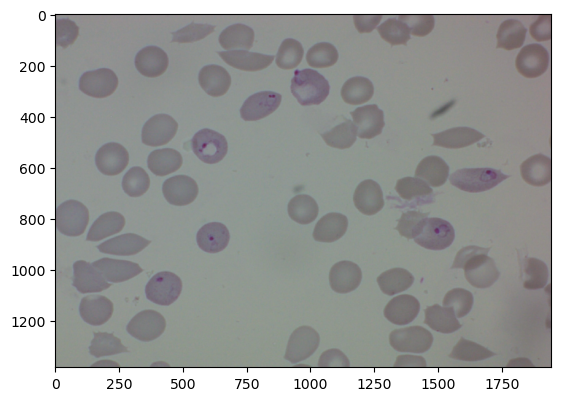

In [6]:
plt.imshow(img)

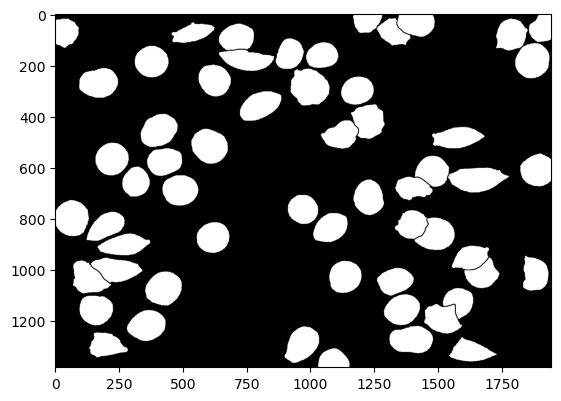

In [7]:
plt.imshow(mask, cmap="gray")

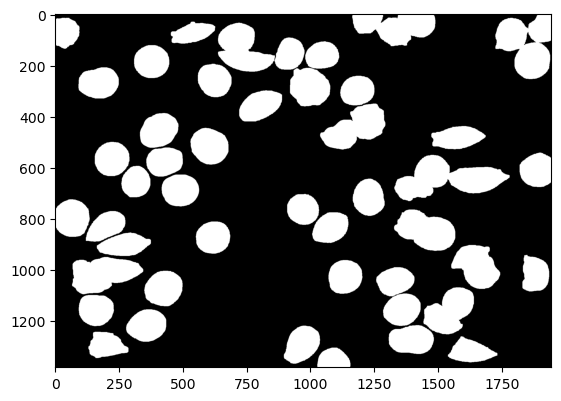

In [8]:
plt.imshow(mask_filtered, cmap="gray")

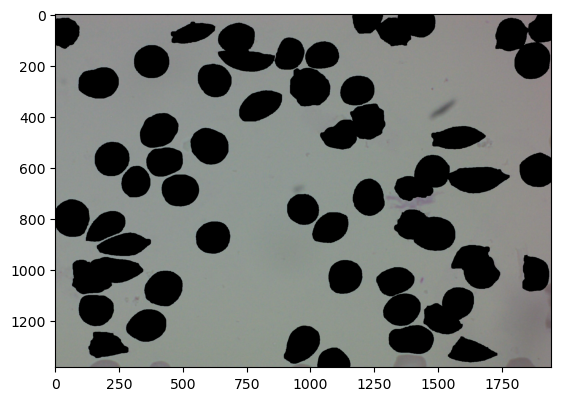

In [9]:
background = img.copy()
background[mask_filtered > 0] = [0, 0, 0]
plt.imshow(background)

In [10]:
def get_background_color(a):
    colors, count = np.unique(a.reshape(-1, a.shape[-1]), axis=0, return_counts=True)
    count_sorted_arg = np.flip(np.argsort(count))
    if np.equal(colors[count_sorted_arg[0]], np.array([0, 0, 0], colors.dtype)).all():
        return colors[count_sorted_arg[1]]
    else:
        return colors[count_sorted_arg[0]]
background_color = get_background_color(background)
background_color

array([144, 151, 146], dtype=uint8)

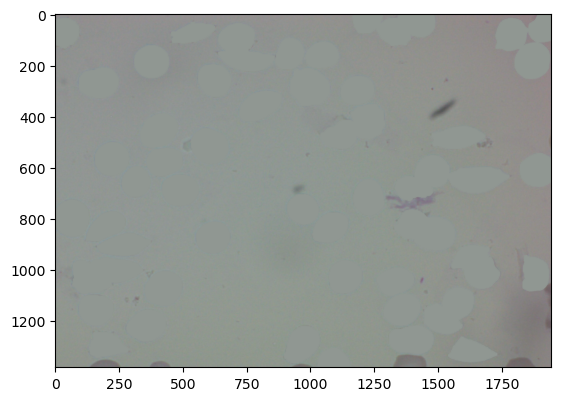

In [11]:
background[mask_filtered > 0] = background_color
plt.imshow(background)

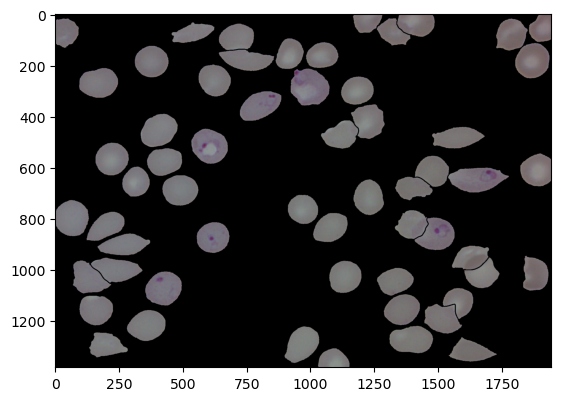

In [12]:
cells_img = img.copy()
cells_img[mask == 0] = [0, 0, 0]
plt.imshow(cells_img)

[123 120 122]


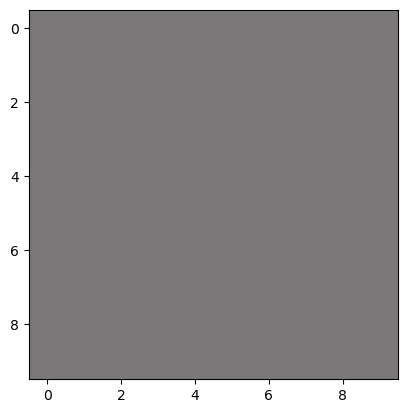

In [13]:
cells_color = get_background_color(cells_img)
print(cells_color)
plt.imshow(np.zeros((10, 10, 3), np.uint8) + cells_color)

In [14]:
n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=4)

58


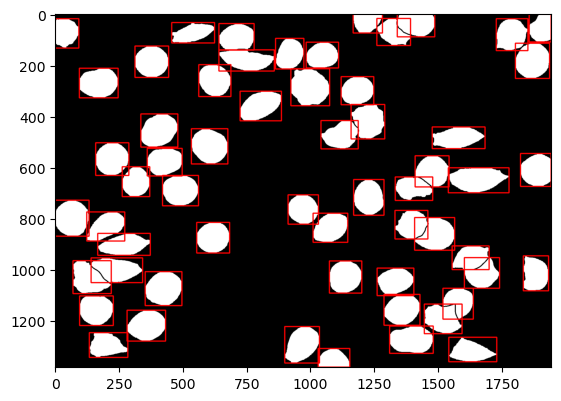

In [15]:
img_w_contours = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
cells = []
for i in range(1, len(stats)):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    if w > 1 and h > 1: # Sometimes weird 1x1 objects are created, gotta exclude those
        curr_cell = img[y:y+h, x:x+w].copy()
        curr_cell[(labels[y:y+h, x:x+w] != i) > 0] = [0, 0, 0]
        cells.append(curr_cell)
        cv2.rectangle(img_w_contours, (x, y), (x + w, y + h), (255, 0, 0), 3)
print(len(cells))
plt.imshow(img_w_contours)

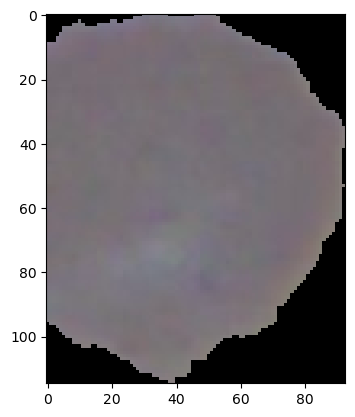

In [16]:
plt.imshow(cells[4])

## Actual thing

In [17]:
dump_dataset_prep = True

In [18]:
def get_background_color(a):
    colors, count = np.unique(a.reshape(-1, a.shape[-1]), axis=0, return_counts=True)
    count_sorted_arg = np.flip(np.argsort(count))
    if np.equal(colors[count_sorted_arg[0]], [0, 0, 0]).all():
        return colors[count_sorted_arg[1]]
    else:
        return colors[count_sorted_arg[0]]

for key, value in dataset_prep.items():
    mask = cv2.imread(value["mask_file"])
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    img = cv2.imread(value["original_file"])
    mask_filtered = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), iterations=3)

    background = img.copy()
    background[mask_filtered > 0] = np.array([0, 0, 0], dtype=np.uint8)
    background_color = get_background_color(background)
    background[mask_filtered > 0] = background_color

    value["background_color"] = background_color
    value["background"] = background

    cells_img = img.copy()
    cells_img[mask == 0] = np.array([0, 0, 0], dtype=np.uint8)
    cells_color = get_background_color(cells_img)
    value["cells_color"] = cells_color

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=4)
    cells = []
    cells_size_range  = [np.max(img.shape), 0]
    for i in range(1, len(stats)):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        if w > 1 and h > 1: # Sometimes weird 1x1 objects are created, gotta exclude those
            curr_cell = img[y:y+h, x:x+w].copy()
            curr_cell[(labels[y:y+h, x:x+w] != i) > 0] = np.array([0, 0, 0], dtype=np.uint8)
            cells.append(curr_cell)
            cells_size_range[0] = min(cells_size_range[0], w, h)
            cells_size_range[1] = max(cells_size_range[1], w, h)
    cells_size_range = list(map(int, cells_size_range))

    value["cells"] = cells
    value["cells_size_range"] = cells_size_range

    if dump_dataset_prep:
        dump_path = files_path + "/generator_dumps/" + key
        os.makedirs(dump_path, exist_ok=True)
        cv2.imwrite(dump_path + "/background.png", background)
        for i, c in enumerate(cells):
            cv2.imwrite(dump_path + "/" + str(i) + ".png", c)
        with open(dump_path + "/additional_data.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "background_color": background_color.tolist(),
                    "cells_size_range": cells_size_range,
                    "cells_color": cells_color.tolist(),
                }, f, ensure_ascii=False)
dataset_prep[list(dataset_prep.keys())[0]].keys()

dict_keys(['mask_file', 'original_file', 'background_color', 'background', 'cells_color', 'cells', 'cells_size_range'])

# Noise

## Demo

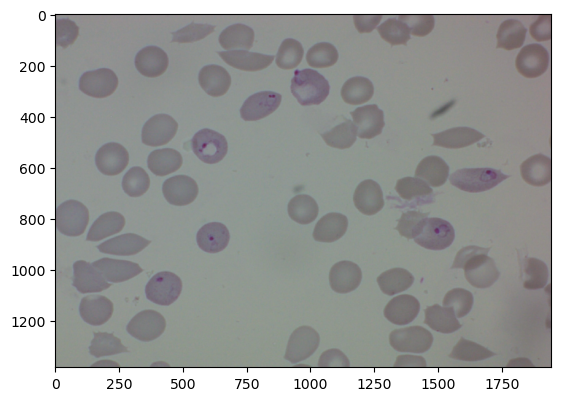

In [19]:
test_subject = 'e6a7743e-4040-40fa-b097-ca6874c469b7'
img = cv2.imread(dataset_prep[test_subject]["original_file"]).astype(float)
img_gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(float)
plt.imshow(img.astype(np.uint8))

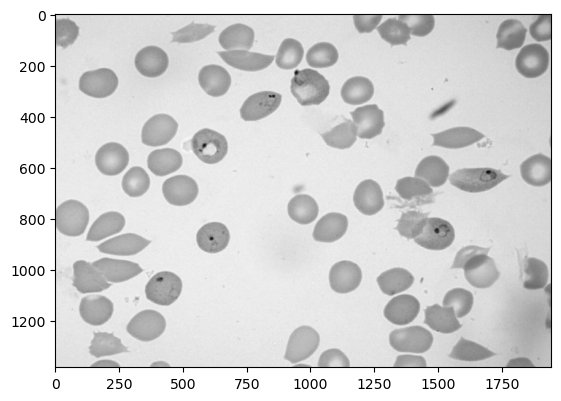

In [20]:
plt.imshow(img_gray.astype(np.uint8), cmap="gray")

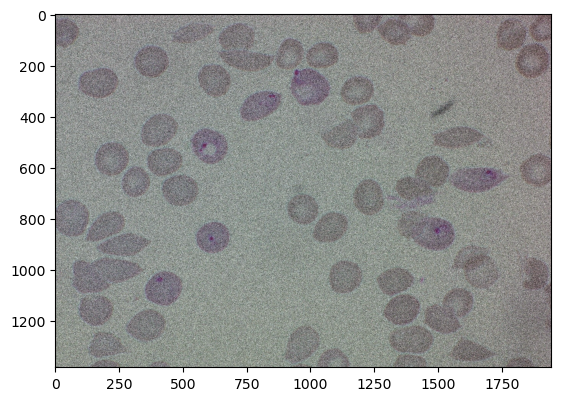

In [21]:
mean = 0
stddev = 50
noise_gauss = np.zeros((img.shape[0], img.shape[1]), float)
cv2.randn(noise_gauss, mean, stddev)
noise_gauss_3 = cv2.merge([noise_gauss, noise_gauss, noise_gauss])
img_noise_gauss = cv2.add(img, noise_gauss_3)
img_noise_gauss = np.clip(img_noise_gauss, 0, 255)
plt.imshow(img_noise_gauss.astype(np.uint8))

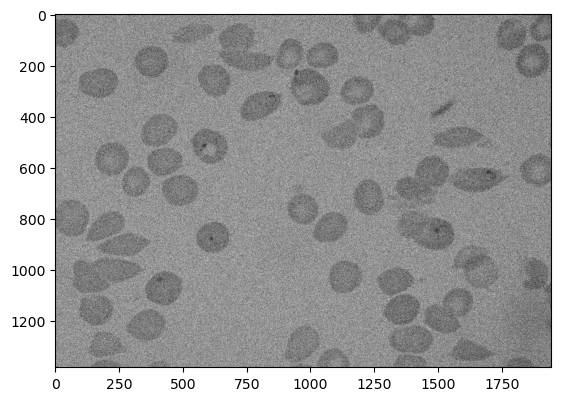

In [22]:
img_noise_gauss_gray = cv2.add(img_gray, noise_gauss)
img_noise_gauss_gray = np.clip(img_noise_gauss_gray, 0, 255)
plt.imshow(img_noise_gauss_gray.astype(np.uint8), cmap="gray")

In [23]:
mse_gauss = mean_squared_error(img_gray, img_noise_gauss_gray)
(ssim_gauss, diff_gauss) = structural_similarity(img_gray.astype(np.uint8), img_noise_gauss_gray.astype(np.uint8), full=True)
print(mse_gauss, ssim_gauss)

2428.2944738437272 0.027876052706475595


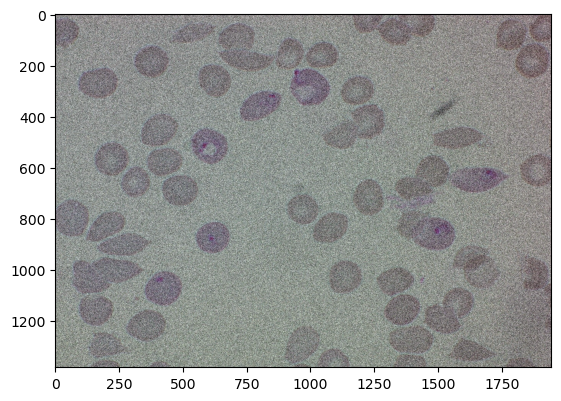

In [24]:
uni_low = -100
uni_high = 100
noise_uni = np.zeros((img.shape[0], img.shape[1]), float)
cv2.randu(noise_uni, uni_low, uni_high)
noise_uni_3 = cv2.merge([noise_uni, noise_uni, noise_uni])
img_noise_uni = cv2.add(img, noise_uni_3)
img_noise_uni = np.clip(img_noise_uni, 0, 255)
plt.imshow(img_noise_uni.astype(np.uint8))

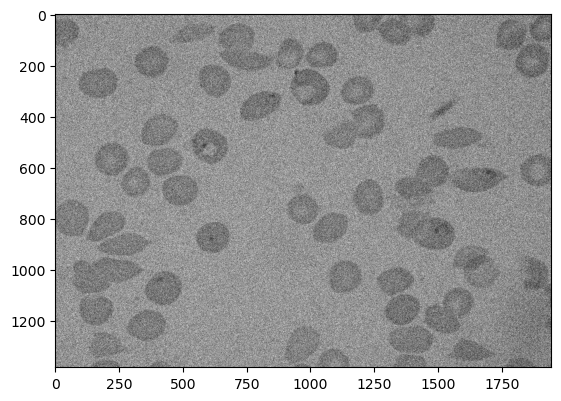

In [25]:
img_noise_uni_gray = cv2.add(img_gray, noise_uni)
img_noise_uni_gray = np.clip(img_noise_uni_gray, 0, 255)
plt.imshow(img_noise_uni_gray.astype(np.uint8), cmap="gray")

In [26]:
mse_uni = mean_squared_error(img_gray, img_noise_uni_gray)
(ssim_uni, diff_uni) = structural_similarity(img_gray.astype(np.uint8), img_noise_uni_gray.astype(np.uint8), full=True)
print(mse_uni, ssim_uni)

3333.5770250787814 0.020142874968486685


# Generator

## Demo

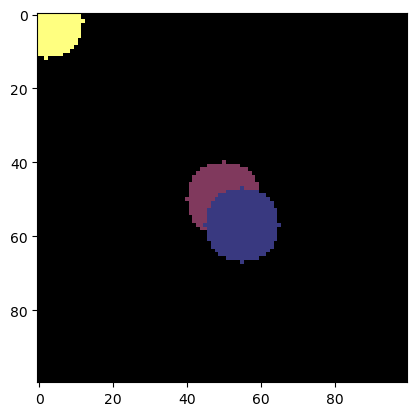

In [27]:
img = np.zeros((100, 100, 3), np.uint8)
mask = np.zeros((100, 100), np.uint8)
temp_mask = mask.copy()
temp_img = img.copy()
cv2.circle(img, center=(50, 50), radius=10, color=(128, 57, 93), thickness=-1)
cv2.circle(mask, center=(50, 50), radius=10, color=255, thickness=-1)
cv2.circle(img, center=(55, 57), radius=10, color=(57, 57, 128), thickness=-1)
cv2.circle(mask, center=(55, 57), radius=10, color=255, thickness=-1)
cv2.circle(img, center=(2, 2), radius=10, color=(255, 255, 128), thickness=-1)
cv2.circle(mask, center=(2, 2), radius=10, color=255, thickness=-1)
plt.imshow(img)

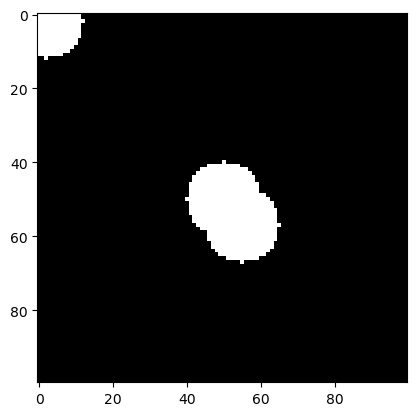

In [28]:
plt.imshow(mask, cmap="gray")

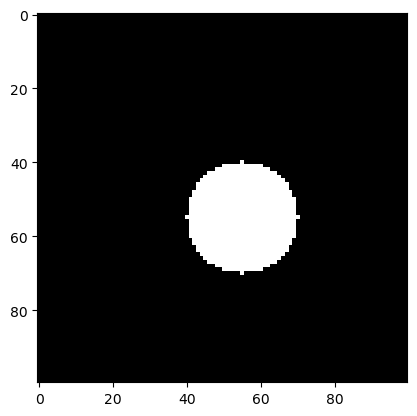

In [29]:
cv2.circle(temp_mask, center=(55, 55), radius=15, color=255, thickness=-1)
cv2.circle(temp_img, center=(55, 55), radius=15, color=(128, 0, 255), thickness=-1)
plt.imshow(temp_mask, cmap="gray")

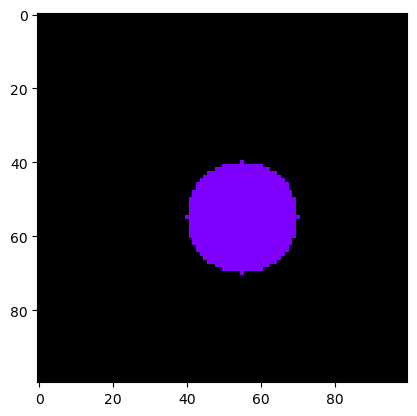

In [30]:
plt.imshow(temp_img)

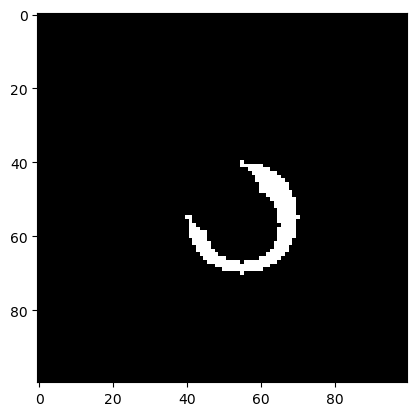

In [31]:
temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(mask))
plt.imshow(temp_mask_without, cmap="gray")

In [32]:
np.count_nonzero(temp_mask_without) / np.count_nonzero(temp_mask)

np.float64(0.34837799717912554)

In [33]:
def my_add_image(a, b, mask):
    a1 = cv2.bitwise_and(a, a, mask=cv2.bitwise_not(mask))
    b1 = cv2.bitwise_and(b, b, mask=mask)
    return cv2.add(a1, b1)

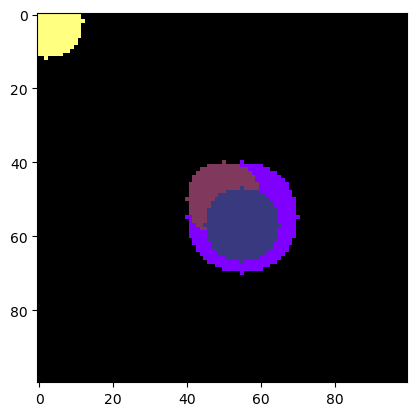

In [34]:
img = my_add_image(img, temp_img, temp_mask_without)
mask = my_add_image(mask, temp_mask, temp_mask_without)
plt.imshow(img)

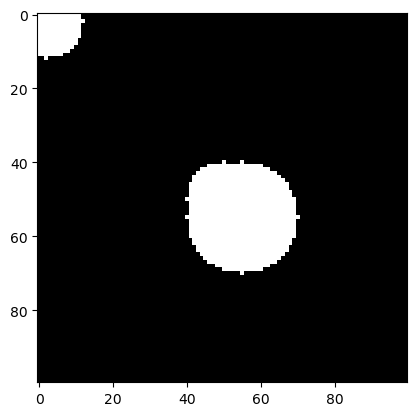

In [35]:
plt.imshow(mask, cmap="gray")

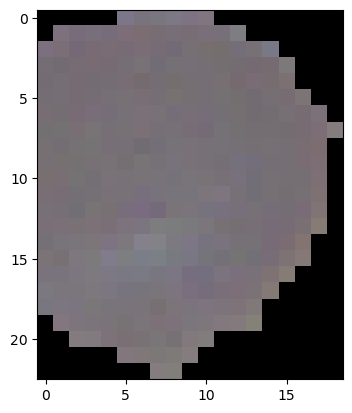

In [36]:
test_subject = 'e6a7743e-4040-40fa-b097-ca6874c469b7'
cell_img = dataset_prep[test_subject]["cells"][4]
cell_img = cv2.resize(cell_img, None, fx=0.2, fy=0.2)
plt.imshow(cell_img)

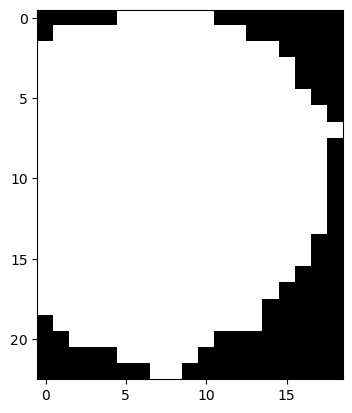

In [37]:
_, cell_mask = cv2.threshold(cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY)
plt.imshow(cell_mask, cmap="gray")

In [38]:
def overlay_image_center(background_img, foreground_img, center_x, center_y):
    # Get dimensions
    h2, w2 = background_img.shape[:2]
    h1, w1 = foreground_img.shape[:2]

    # Calculate top-left corner of foreground_img based on center position
    x1_start = center_x - w1 // 2
    y1_start = center_y - h1 // 2

    # Calculate boundaries for foreground_img placement
    x1_end = x1_start + w1
    y1_end = y1_start + h1

    # Calculate valid region in background_img (clamp to bounds)
    x2_start = max(0, x1_start)
    y2_start = max(0, y1_start)
    x2_end = min(w2, x1_end)
    y2_end = min(h2, y1_end)

    # Calculate corresponding region in foreground_img
    x1_crop_start = max(0, -x1_start)
    y1_crop_start = max(0, -y1_start)
    x1_crop_end = x1_crop_start + (x2_end - x2_start)
    y1_crop_end = y1_crop_start + (y2_end - y2_start)

    # Create a copy to avoid modifying original
    result = background_img.copy()

    # Only overlay if there's a valid overlap region
    if x2_end > x2_start and y2_end > y2_start:
        # Extract the valid region from foreground_img
        foreground_img_region = foreground_img[y1_crop_start:y1_crop_end, x1_crop_start:x1_crop_end]

        # Overlay onto background_img
        result[y2_start:y2_end, x2_start:x2_end] = foreground_img_region

    return result

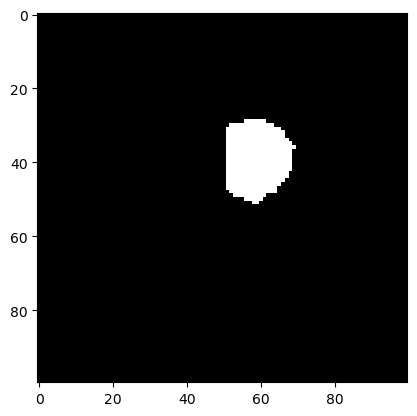

In [39]:
temp_mask.fill(0)
temp_img.fill(0)
x, y = (60, 40)
temp_mask = overlay_image_center(temp_mask, cell_mask, x, y)
temp_img = overlay_image_center(temp_img, cell_img, x, y)
plt.imshow(temp_mask, cmap="gray")

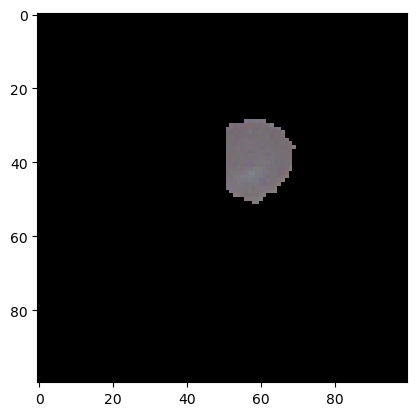

In [40]:
plt.imshow(temp_img)

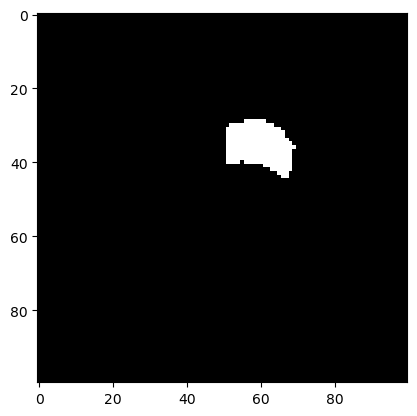

In [41]:
temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(mask))
plt.imshow(temp_mask_without, cmap="gray")

In [42]:
np.count_nonzero(temp_mask_without) / np.count_nonzero(temp_mask)

np.float64(0.6238805970149254)

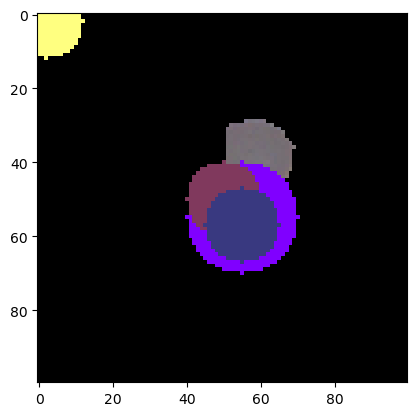

In [43]:
img = my_add_image(img, temp_img, temp_mask_without)
mask = my_add_image(mask, temp_mask, temp_mask_without)
plt.imshow(img)

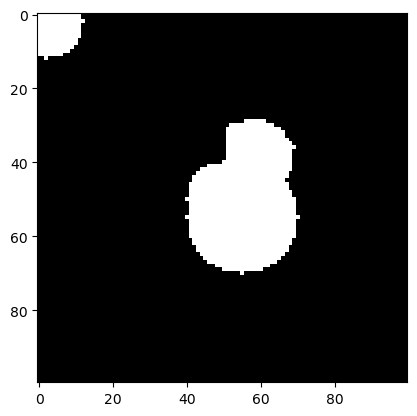

In [44]:
plt.imshow(mask, cmap="gray")

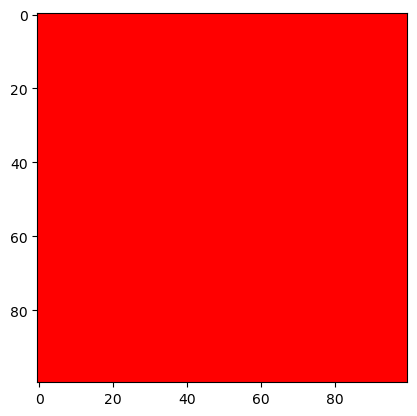

In [45]:
background = np.zeros_like(img) + np.array([255, 0, 0], dtype=np.uint8)
plt.imshow(background)

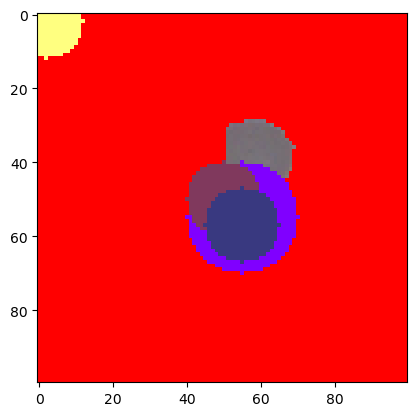

In [46]:
background = my_add_image(background, img, mask)
plt.imshow(background)

## Actual thing (with noise generation)

In [47]:
class BloodCellsDataset(Dataset):

    def __init__(
        self,
        img_size: tuple[int, int], # (w, h)
        dataset_size: int,
        dataset_prep: dict,
        p_background_solid: float = 0.5,
        p_cell_artificial: float = 0.5,
        min_cells_count: int = 40,
        max_cells_count: int = 100,
        min_cell_coverage: float = 0.25,
        gauss_noise_params_ranges: tuple[tuple[float, float], tuple[float, float]] = (0, 50),
        uniform_noise_params_ranges: tuple[tuple[float, float], tuple[float, float]] = (-100, 100),
        p_gauss_noise_choice: float = 0.5,
        noise_clamp: bool = True, # clamps resulting noisy image
        noise_grayscale: bool = True,
        mix_cells_datasets: bool = False,
    ):
        self.img_size = img_size
        assert(img_size[0] > 0 and img_size[1] > 0)
        self.dataset_size = dataset_size
        assert(dataset_size > 0)
        self.dataset_prep = dataset_prep
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        assert(0 < min_cells_count <= max_cells_count)
        self.p_background_solid = p_background_solid
        assert(0 <= p_background_solid <= 1)
        self.p_cell_artificial = p_cell_artificial
        assert(0 <= p_cell_artificial <= 1)
        self.min_cell_coverage = min_cell_coverage
        assert(0 <= min_cell_coverage <= 1)
        _gauss_noise_params_ranges = []
        for i in range(2):
            if not hasattr(gauss_noise_params_ranges[i], "__getitem__"):
                _gauss_noise_params_ranges.append((gauss_noise_params_ranges[i], gauss_noise_params_ranges[i]))
            else:
                _gauss_noise_params_ranges.append(gauss_noise_params_ranges[i])
            assert(_gauss_noise_params_ranges[i][0] <= _gauss_noise_params_ranges[i][1])
        _gauss_noise_params_ranges = tuple(_gauss_noise_params_ranges)
        assert(_gauss_noise_params_ranges[1][0] >= 0)
        assert(_gauss_noise_params_ranges[1][1] >= 0)
        self.gauss_noise_params_ranges = _gauss_noise_params_ranges
        _uniform_noise_params_ranges = []
        for i in range(2):
            if not hasattr(uniform_noise_params_ranges[i], "__getitem__"):
                _uniform_noise_params_ranges.append((uniform_noise_params_ranges[i], uniform_noise_params_ranges[i]))
            else:
                _uniform_noise_params_ranges.append(uniform_noise_params_ranges[i])
        _uniform_noise_params_ranges = tuple(_uniform_noise_params_ranges)
        self.uniform_noise_params_ranges = _uniform_noise_params_ranges
        self.p_gauss_noise_choice = p_gauss_noise_choice
        assert(0 <= p_gauss_noise_choice <= 1)
        self.noise_clamp = noise_clamp
        self.noise_grayscale = noise_grayscale
        self.mix_cells_datasets = mix_cells_datasets

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, item: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        assert(item >= 0 and item < self.__len__())
        # Determine cells count
        cells_count = np.random.randint(self.min_cells_count, self.max_cells_count)
        # Select first cells dataset
        cells_dataset_key = self.choose_random_dataset()
        cells_dataset = self.dataset_prep[cells_dataset_key]
        cells_size_range = cells_dataset["cells_size_range"]
        # Generate background
        clean_img = self.select_background()
        # Init masks and imgs
        cells_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), clean_img.dtype)
        temp_mask = cells_mask.copy()
        cells_img = np.zeros_like(clean_img)
        temp_img = np.zeros_like(cells_img)
        # Begin
        actual_cells_count = 0
        for i in range(cells_count):
            for _max_attempts in range(999):
                # Reset temp
                temp_mask.fill(0)
                temp_img.fill(0)
                # Select another cells dataset if mix_cells_datasets
                if self.mix_cells_datasets:
                    cells_dataset_key = self.choose_random_dataset()
                    cells_dataset = self.dataset_prep[cells_dataset_key]
                    cells_size_range = cells_dataset["cells_size_range"]
                # Select cell pos
                x = np.random.randint(cells_img.shape[1])
                y = np.random.randint(cells_img.shape[0])
                # select if generating artificial cell
                use_artificial_cell = bool(np.random.choice(2, p=[1-self.p_cell_artificial, self.p_cell_artificial]))

                if use_artificial_cell:
                    rad = np.random.randint(cells_size_range[0]//2, cells_size_range[1]//2)
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=cells_dataset["cells_color"].tolist(), thickness=-1)
                    stroke_color = 255 - cells_dataset["cells_color"]
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=stroke_color.tolist(), thickness=3)
                else:
                    cell_index = np.random.randint(len(cells_dataset["cells"]))
                    cell_img = cells_dataset["cells"][cell_index]
                    _, cell_mask = cv2.threshold(cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY)
                    temp_mask = self.overlay_image_center(temp_mask, cell_mask, x, y)
                    temp_img = self.overlay_image_center(temp_img, cell_img, x, y)
                # Insert generated cell
                temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                # Check coverage
                coverage = np.count_nonzero(temp_mask_without) / np.count_nonzero(temp_mask)
                if coverage >= self.min_cell_coverage:
                    # Add the cell
                    cells_img = self.add_image_with_mask(cells_img, temp_img, temp_mask_without)
                    cells_mask = self.add_image_with_mask(cells_mask, temp_mask, temp_mask_without)
                    actual_cells_count += 1
                    break
            else:
                print("Warning: loop ended earlier")
                break
        # add background
        clean_img = self.add_image_with_mask(clean_img, cells_img, cells_mask)
        # resize
        clean_img = cv2.resize(clean_img, dsize=(self.img_size[1], self.img_size[0])).astype(float)
        # create noisy
        noisy_img, noise_type = self.add_noise(clean_img)
        return (clean_img, noisy_img, actual_cells_count, noise_type)

    def choose_random_dataset(self) -> str:
        return np.random.choice(list(self.dataset_prep.keys()))

    def select_background(self) -> np.ndarray[np.uint8]:
        background_dataset_key = self.choose_random_dataset()
        background_dataset = self.dataset_prep[background_dataset_key]
        use_solid_background = bool(np.random.choice(2, p=[1-self.p_background_solid, self.p_background_solid]))
        clean_img = None
        if use_solid_background:
            clean_img = np.zeros_like(background_dataset["background"]) + background_dataset["background_color"]
        else:
            clean_img = background_dataset["background"].copy()
        return clean_img

    def add_noise(self, clean_img: np.ndarray[float]) -> np.ndarray[float]:
        noise_img = np.zeros((clean_img.shape[0], clean_img.shape[1]), float)
        noisy_img = None
        use_gauss_noise = bool(np.random.choice(2, p=[1-self.p_gauss_noise_choice, self.p_gauss_noise_choice]))
        noise_type = "gauss" if use_gauss_noise else "uniform"
        if use_gauss_noise:
            mean = np.random.uniform(
                self.gauss_noise_params_ranges[0][0],
                self.gauss_noise_params_ranges[0][1]
            )
            std = np.random.uniform(
                self.gauss_noise_params_ranges[1][0],
                self.gauss_noise_params_ranges[1][1]
            )
            cv2.randn(noise_img, mean, std)
        else:
            low = np.random.uniform(
                self.uniform_noise_params_ranges[0][0],
                self.uniform_noise_params_ranges[0][1]
            )
            high = np.random.uniform(
                self.uniform_noise_params_ranges[1][0],
                self.uniform_noise_params_ranges[1][1]
            )
            cv2.randu(noise_img, low, high)
        if not self.noise_grayscale:
            noise_img = cv2.merge([noise_img, noise_img, noise_img])
            noisy_img = cv2.add(clean_img, noise_img)
        else:
            clean_img_grayscale = cv2.cvtColor(clean_img.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(float)
            noisy_img = cv2.add(clean_img_grayscale, noise_img)
        if self.noise_clamp:
            noisy_img = np.clip(noisy_img, 0, 255)
        return (noisy_img, noise_type)

    @staticmethod
    def add_image_with_mask(a, b, mask):
        a1 = cv2.bitwise_and(a, a, mask=cv2.bitwise_not(mask))
        b1 = cv2.bitwise_and(b, b, mask=mask)
        return cv2.add(a1, b1)

    @staticmethod
    def overlay_image_center(background_img, foreground_img, center_x, center_y):
        # Get dimensions
        h2, w2 = background_img.shape[:2]
        h1, w1 = foreground_img.shape[:2]

        # Calculate top-left corner of foreground_img based on center position
        x1_start = center_x - w1 // 2
        y1_start = center_y - h1 // 2

        # Calculate boundaries for foreground_img placement
        x1_end = x1_start + w1
        y1_end = y1_start + h1

        # Calculate valid region in background_img (clamp to bounds)
        x2_start = max(0, x1_start)
        y2_start = max(0, y1_start)
        x2_end = min(w2, x1_end)
        y2_end = min(h2, y1_end)

        # Calculate corresponding region in foreground_img
        x1_crop_start = max(0, -x1_start)
        y1_crop_start = max(0, -y1_start)
        x1_crop_end = x1_crop_start + (x2_end - x2_start)
        y1_crop_end = y1_crop_start + (y2_end - y2_start)

        # Create a copy to avoid modifying original
        result = background_img.copy()

        # Only overlay if there's a valid overlap region
        if x2_end > x2_start and y2_end > y2_start:
            # Extract the valid region from foreground_img
            foreground_img_region = foreground_img[y1_crop_start:y1_crop_end, x1_crop_start:x1_crop_end]

            # Overlay onto background_img
            result[y2_start:y2_end, x2_start:x2_end] = foreground_img_region

        return result

In [48]:
blood_cells_dataset = BloodCellsDataset((1200, 1600), 10, dataset_prep)

61


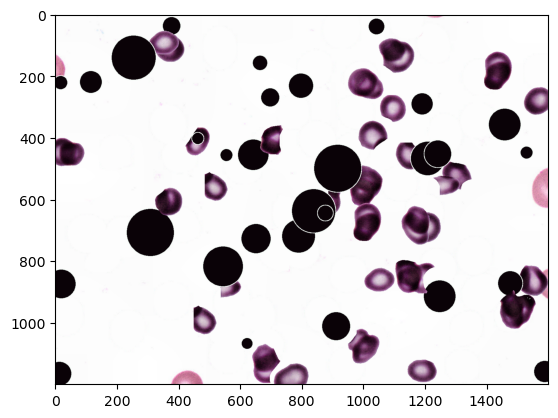

In [49]:
sample = blood_cells_dataset[0]
print(sample[2])
plt.imshow(sample[0].astype(np.uint8))

gauss


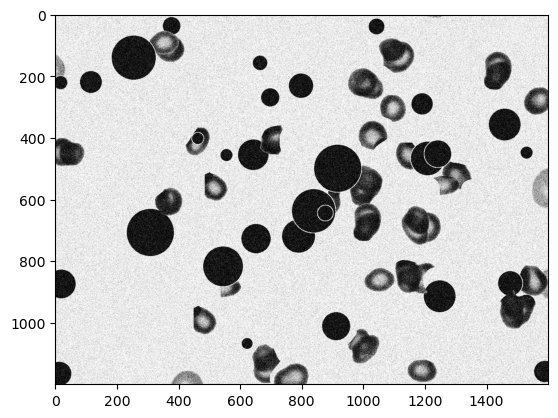

In [50]:
print(sample[3])
plt.imshow(sample[1].astype(np.uint8), cmap="gray")

In [51]:
sample_grayscale = (
    cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY),
    #cv2.cvtColor(sample[1].astype(np.uint8), cv2.COLOR_BGR2GRAY) # when noisy is RGB
    sample[1].astype(np.uint8) # when noisy is grayscale already
)
mse = mean_squared_error(sample_grayscale[0], sample_grayscale[1])
(ssim, diff) = structural_similarity(sample_grayscale[0], sample_grayscale[1], full=True)
print(mse, ssim)

1348.4815786458332 0.11301485733416444


# Denoising

https://stackoverflow.com/questions/9786102/how-do-i-parallelize-a-simple-python-loop/59385935#59385935 (but I decided not to run in parallel)

In [62]:
filters = [
    {
        "name": "median",
        "func": cv2.medianBlur,
        "params_range": [
            range(1, 15+1, 2),
        ],
    },
    {
        "name": "gaussian",
        "func": lambda img, sz: cv2.GaussianBlur(img, (sz, sz), 0),
        "params_range": [
            range(1, 15+1, 2),
        ],
    },
    {
        "name": "bilateral",
        "func": lambda img, sigma: cv2.bilateralFilter(img, 9, sigma, sigma),
        "params_range": [
            range(50, 150+1, 10),
        ],
    },
    {
        "name": "nl means",
        "func": cv2.fastNlMeansDenoising,
        "params_range": [
            range(10, 40+1, 2),
        ],
    }
]

In [63]:
def do_denoise_round(img_gray: np.ndarray[np.uint8], img_noisy_gray: np.ndarray[np.uint8], filter_dict: dict, res_arr: list, i: int) -> None:
    best_mse = mean_squared_error(img_gray, img_noisy_gray)
    best_ssim = structural_similarity(img_gray, img_noisy_gray, full=False)
    best_params_mse = []
    best_params_ssim = []
    for params in itertools.product(*filter_dict["params_range"]):
        filtered_img_gray = filter_dict["func"](img_noisy_gray, *params)
        mse = mean_squared_error(img_gray, filtered_img_gray)
        ssim = structural_similarity(img_gray, filtered_img_gray, full=False)
        if mse < best_mse:
            best_mse = mse
            best_params_mse = params
        if ssim > best_ssim:
            best_ssim = ssim
            best_params_ssim = params
    res_arr[i] = {
        "best_mse": best_mse,
        "best_ssim": best_ssim,
        "best_params_mse": best_params_mse,
        "best_params_ssim": best_params_ssim,
    }


In [64]:
test_images = 100
denoising_dataset = BloodCellsDataset((600, 800), test_images, dataset_prep)

In [65]:
noise_types = []
base_metrics = {
    "mse": [],
    "ssim": [],
}
denoise_results = {}
for f in filters:
    denoise_results[f["name"]] = {
        "best_mse": [],
        "best_ssim": [],
        "best_params_mse": [],
        "best_params_ssim": [],
    }

for img_ind in range(test_images):
    temp_result = [None] * len(filters)
    sample = denoising_dataset[img_ind]
    img_gray = cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY)
    img_noisy_gray = sample[1].astype(np.uint8)
    assert(len(img_noisy_gray.shape) == 2)
    base_metrics["mse"].append(mean_squared_error(img_gray, img_noisy_gray))
    base_metrics["ssim"].append(structural_similarity(img_gray, img_noisy_gray, full=False))
    noise_types.append(sample[3])
    for i, filter_dict in enumerate(filters):
        do_denoise_round(img_gray, img_noisy_gray, filter_dict, temp_result, i)
    for i, filter_dict in enumerate(filters):
        filter_name = filter_dict["name"]
        for key, value in temp_result[i].items():
            denoise_results[filter_name][key].append(value)

# to numpy
noise_types_int = []
for t in noise_types:
    if t == "gauss":
        noise_types_int.append(0)
    else:
        noise_types_int.append(1)
noise_types_int = np.array(noise_types_int)
for key in base_metrics.keys():
    base_metrics[key] = np.array(base_metrics[key])
for f in denoise_results.values():
    for key in f.keys():
        f[key] = np.array(f[key])

In [66]:
def plot_denoising_result_with_types(denoise_results, noise_types_int):
    n = len(noise_types_int)
    fig, axes = plt.subplots(1 + len(denoise_results.keys()), 2, figsize=(20, 10 * len(denoise_results.keys())))
    fig.suptitle("Blue Circle - gaussian noise, Red Square - uniform noise")
    mask_gauss = noise_types_int == 0 # gauss
    mask_uniform = noise_types_int == 1 # uniform
    x = np.arange(n)
    for metric_i, metric in enumerate(("mse", "ssim")):
        axes[0, metric_i].set_title(metric)
        if metric_i == 0:
            axes[0, metric_i].invert_yaxis()
        for key, value in denoise_results.items():
            axes[0, metric_i].plot(x[mask_gauss], value["best_" + metric][mask_gauss], "bo")
            axes[0, metric_i].plot(x[mask_uniform], value["best_" + metric][mask_uniform], "rs")
            axes[0, metric_i].plot(x, value["best_" + metric], label=key)
        axes[0, metric_i].legend()
    i = 1
    for key, value in denoise_results.items():
        for metric_i, metric in enumerate(("mse", "ssim")):
            axes[i, metric_i].set_title(metric)
            if metric_i == 0:
                axes[i, metric_i].invert_yaxis()
            axes[i, metric_i].plot(x[mask_gauss], value["best_" + metric][mask_gauss], "bo")
            axes[i, metric_i].plot(x[mask_uniform], value["best_" + metric][mask_uniform], "rs")
            axes[i, metric_i].plot(x, value["best_" + metric], label=key)
            axes[i, metric_i].legend()
        i += 1

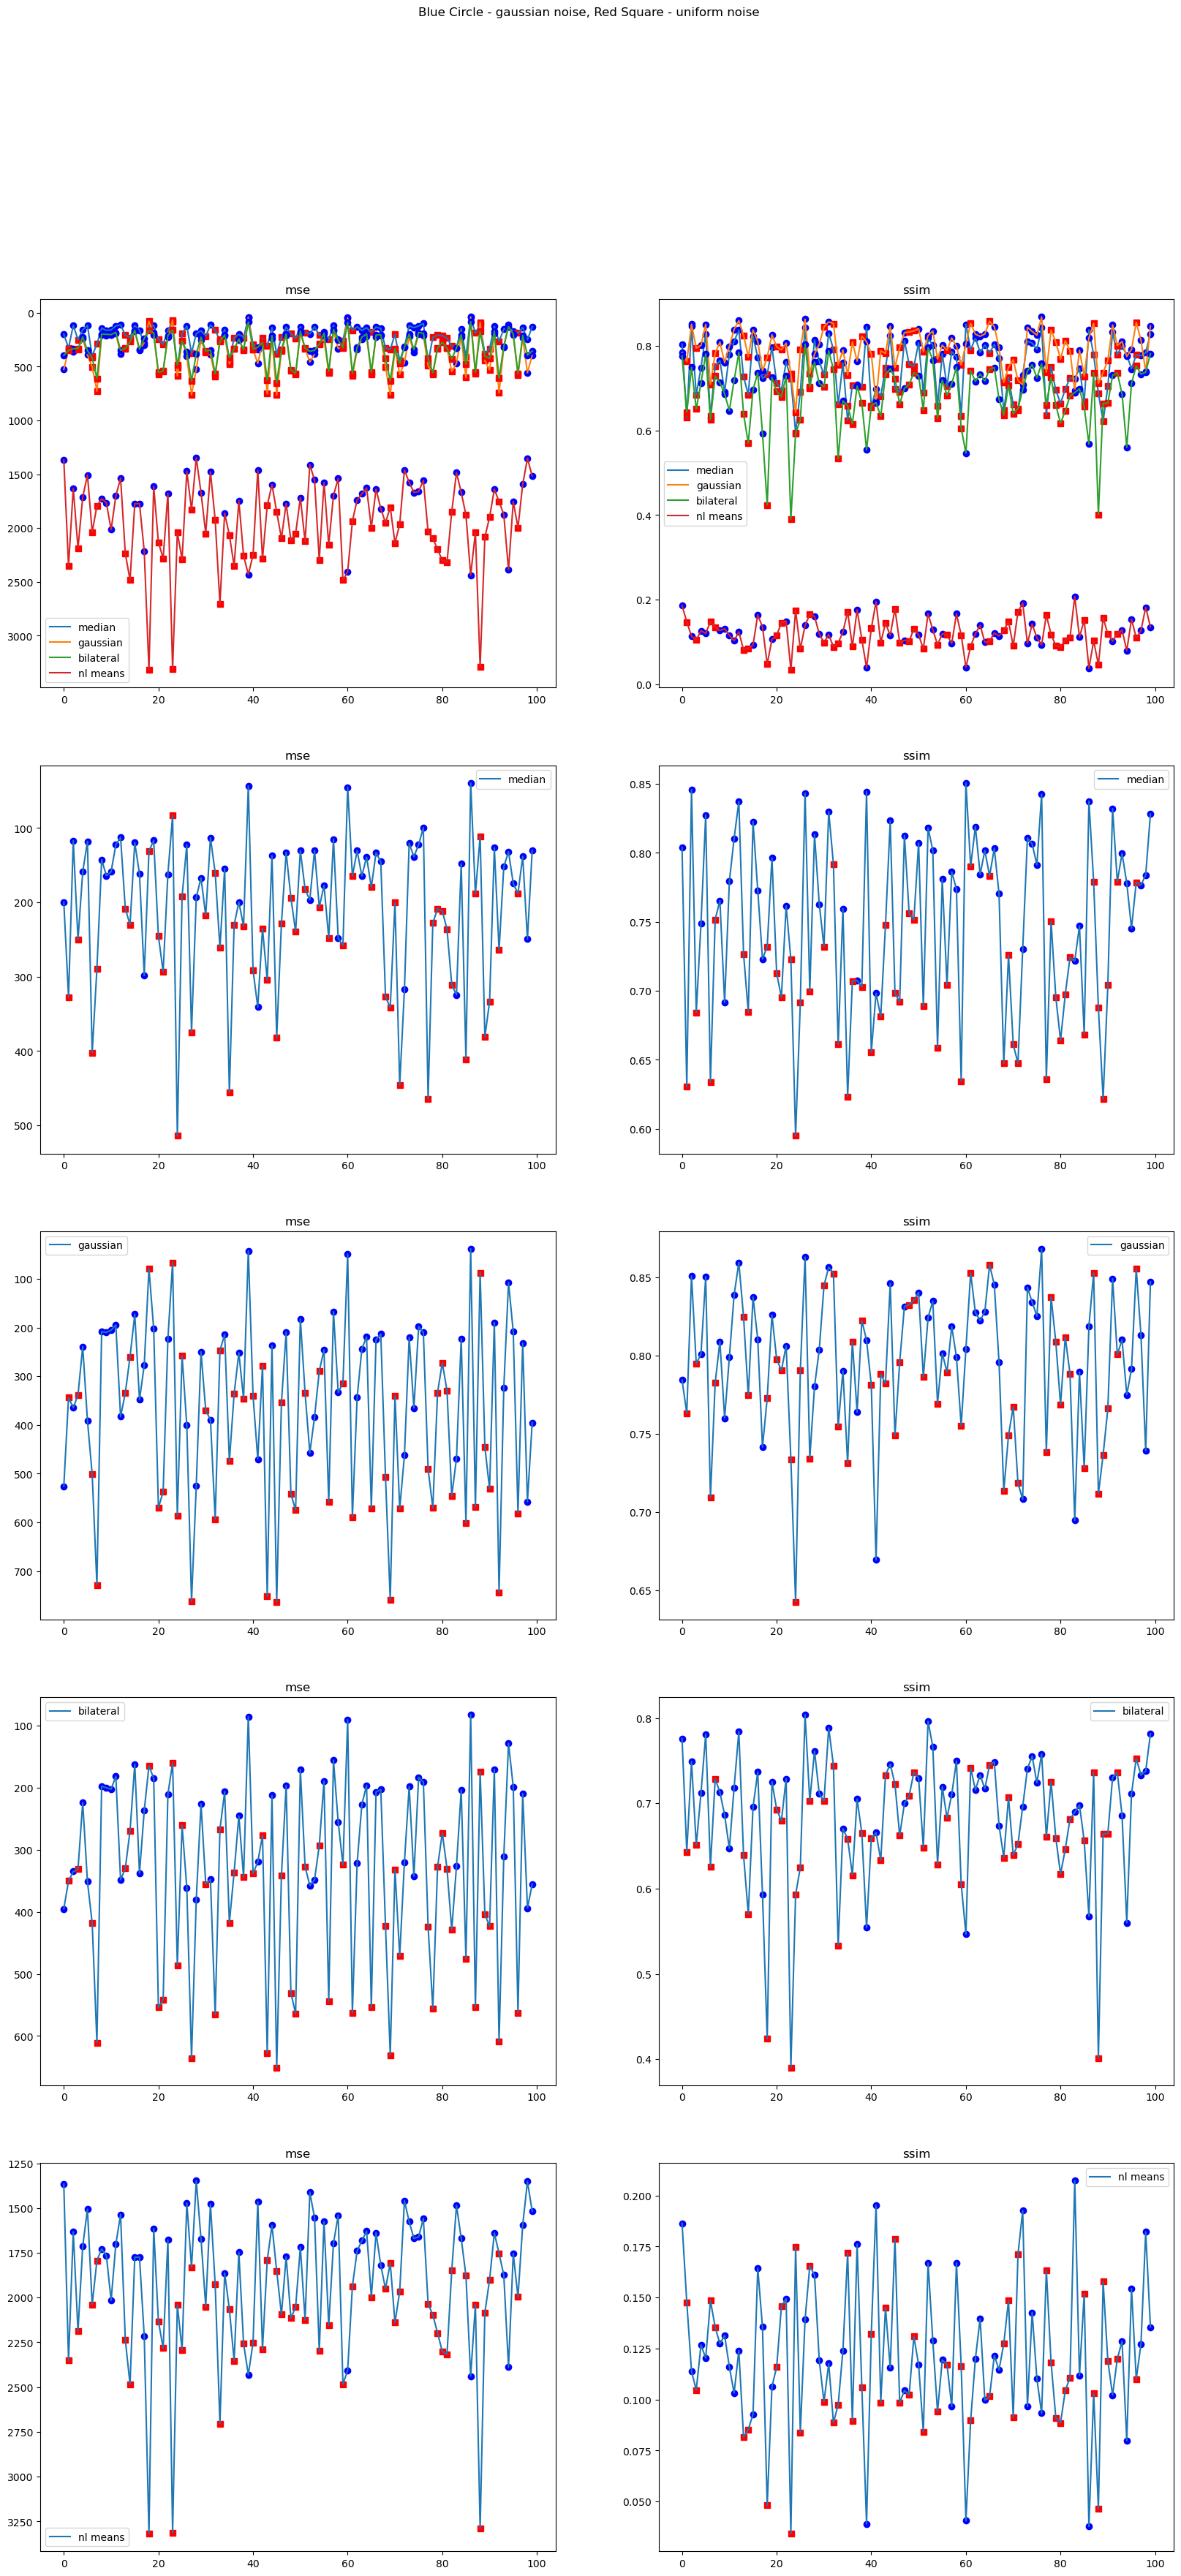

In [67]:
plot_denoising_result_with_types(denoise_results, noise_types_int)

In [68]:
def plot_denoising_result_specific_type(denoise_results, noise_types_int, noise_type, noise_type_label):
    n = len(noise_types_int)
    fig, axes = plt.subplots(1 + len(denoise_results.keys()), 2, figsize=(20, 10 * len(denoise_results.keys())))
    fig.suptitle(noise_type_label)
    mask = noise_types_int == noise_type
    for metric_i, metric in enumerate(("mse", "ssim")):
        axes[0, metric_i].set_title(metric)
        if metric_i == 0:
            axes[0, metric_i].invert_yaxis()
        for key, value in denoise_results.items():
            axes[0, metric_i].plot(value["best_" + metric][mask], label=key, marker="o")
        axes[0, metric_i].legend()
    i = 1
    for key, value in denoise_results.items():
        for metric_i, metric in enumerate(("mse", "ssim")):
            axes[i, metric_i].set_title(metric)
            if metric_i == 0:
                axes[i, metric_i].invert_yaxis()
            axes[i, metric_i].plot(value["best_" + metric][mask], label=key, marker="o")
            axes[i, metric_i].legend()
        i += 1

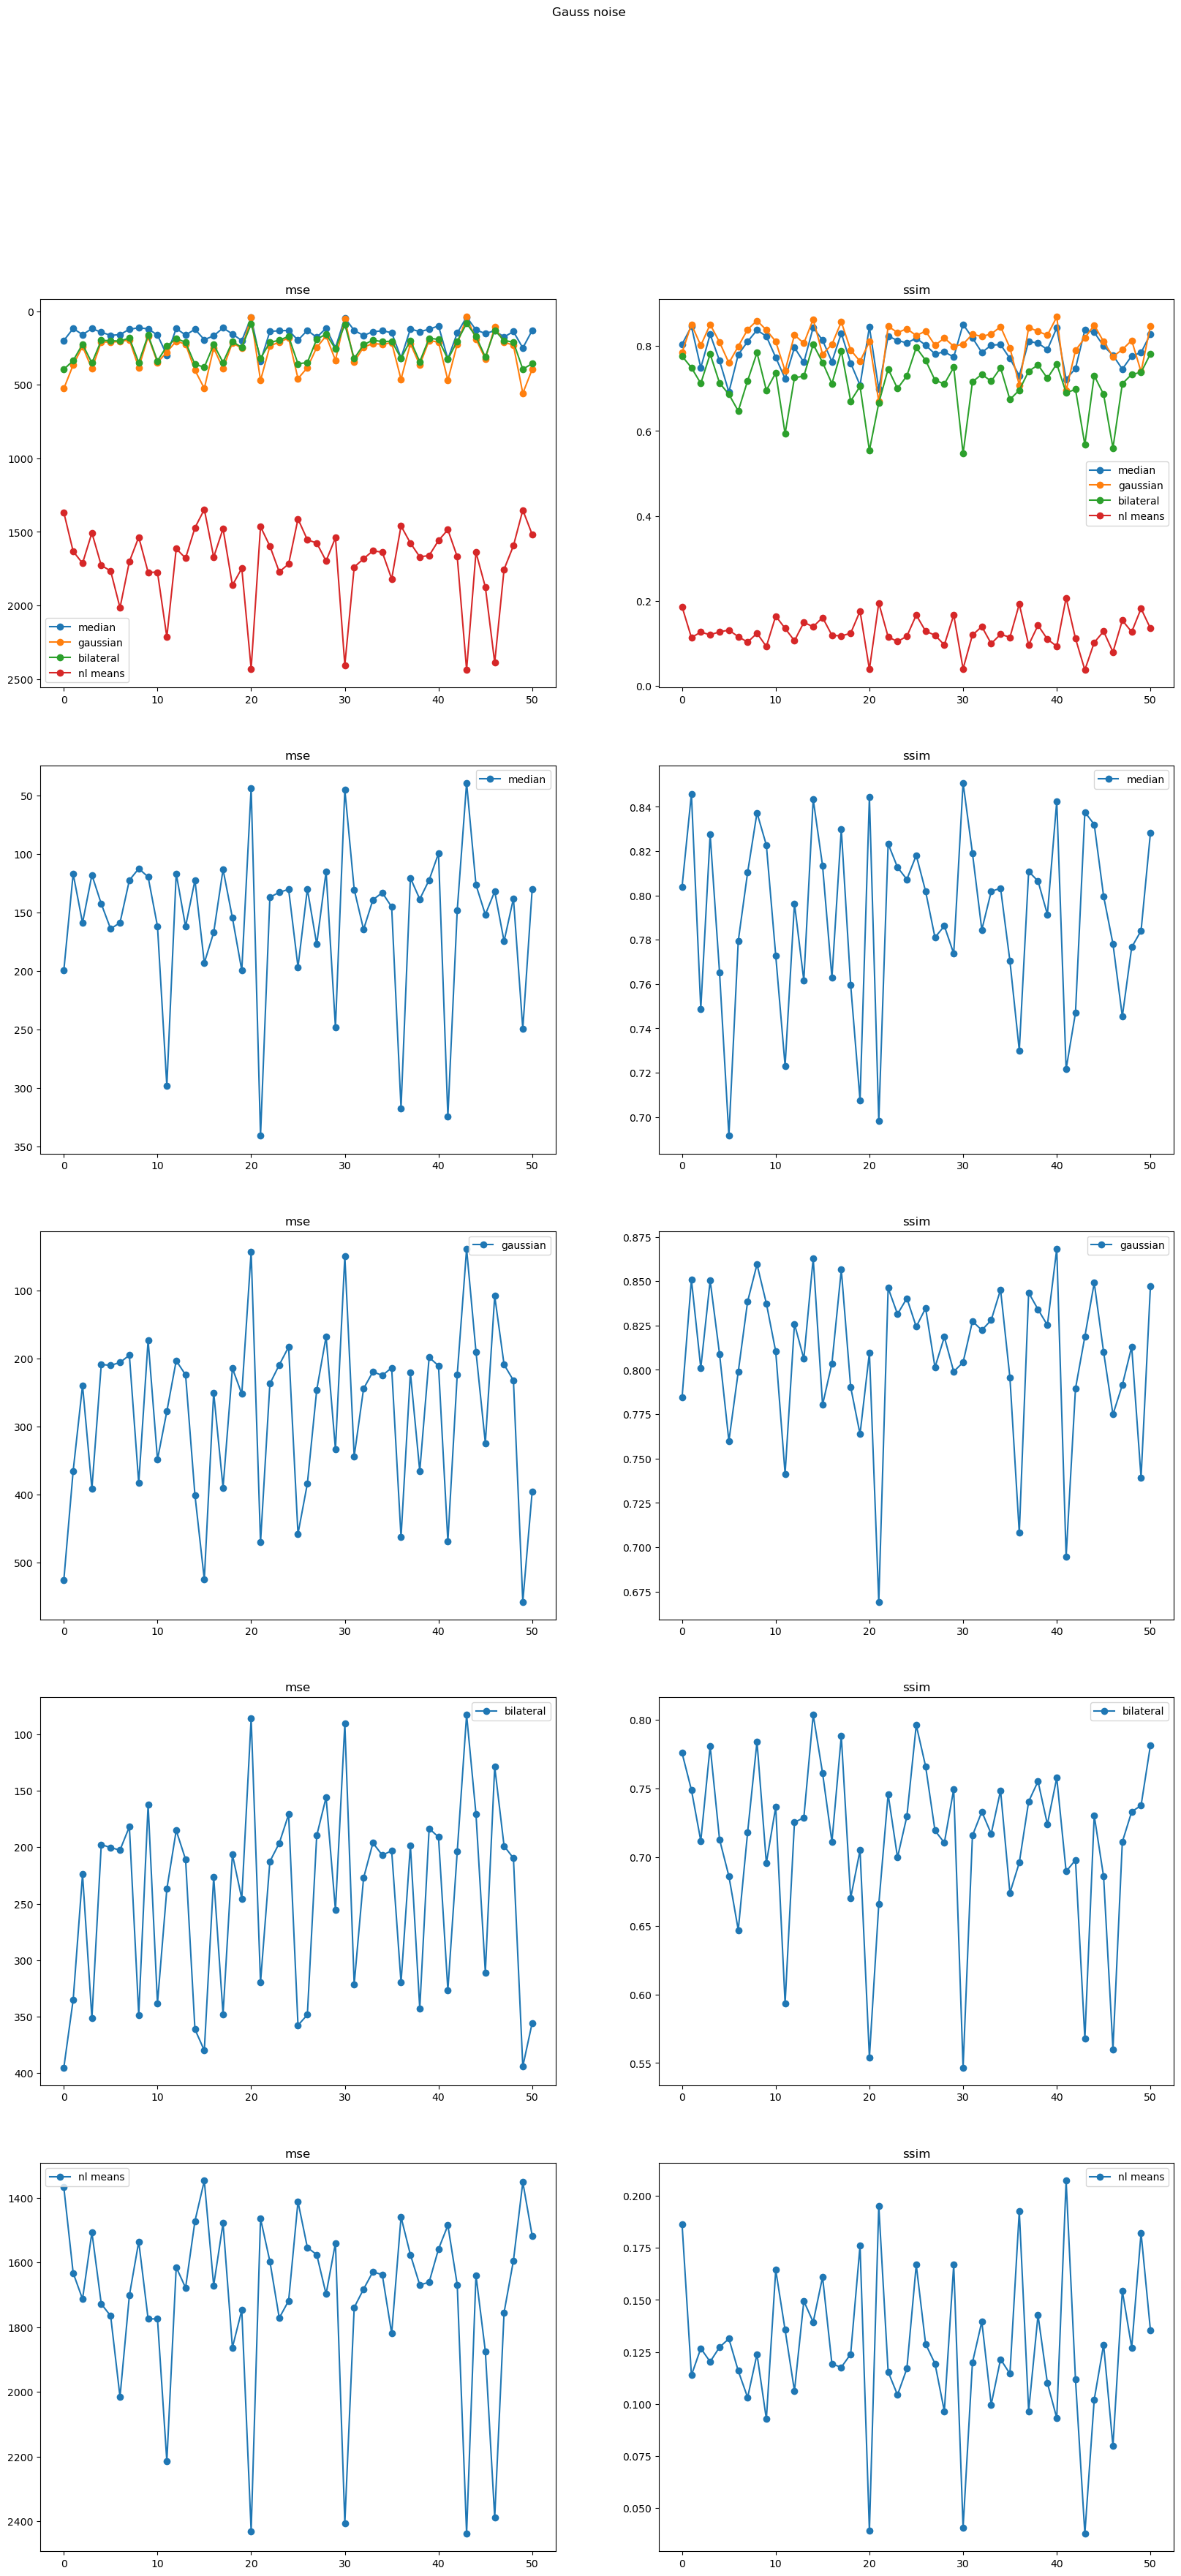

In [69]:
plot_denoising_result_specific_type(denoise_results, noise_types_int, 0, "Gauss noise")

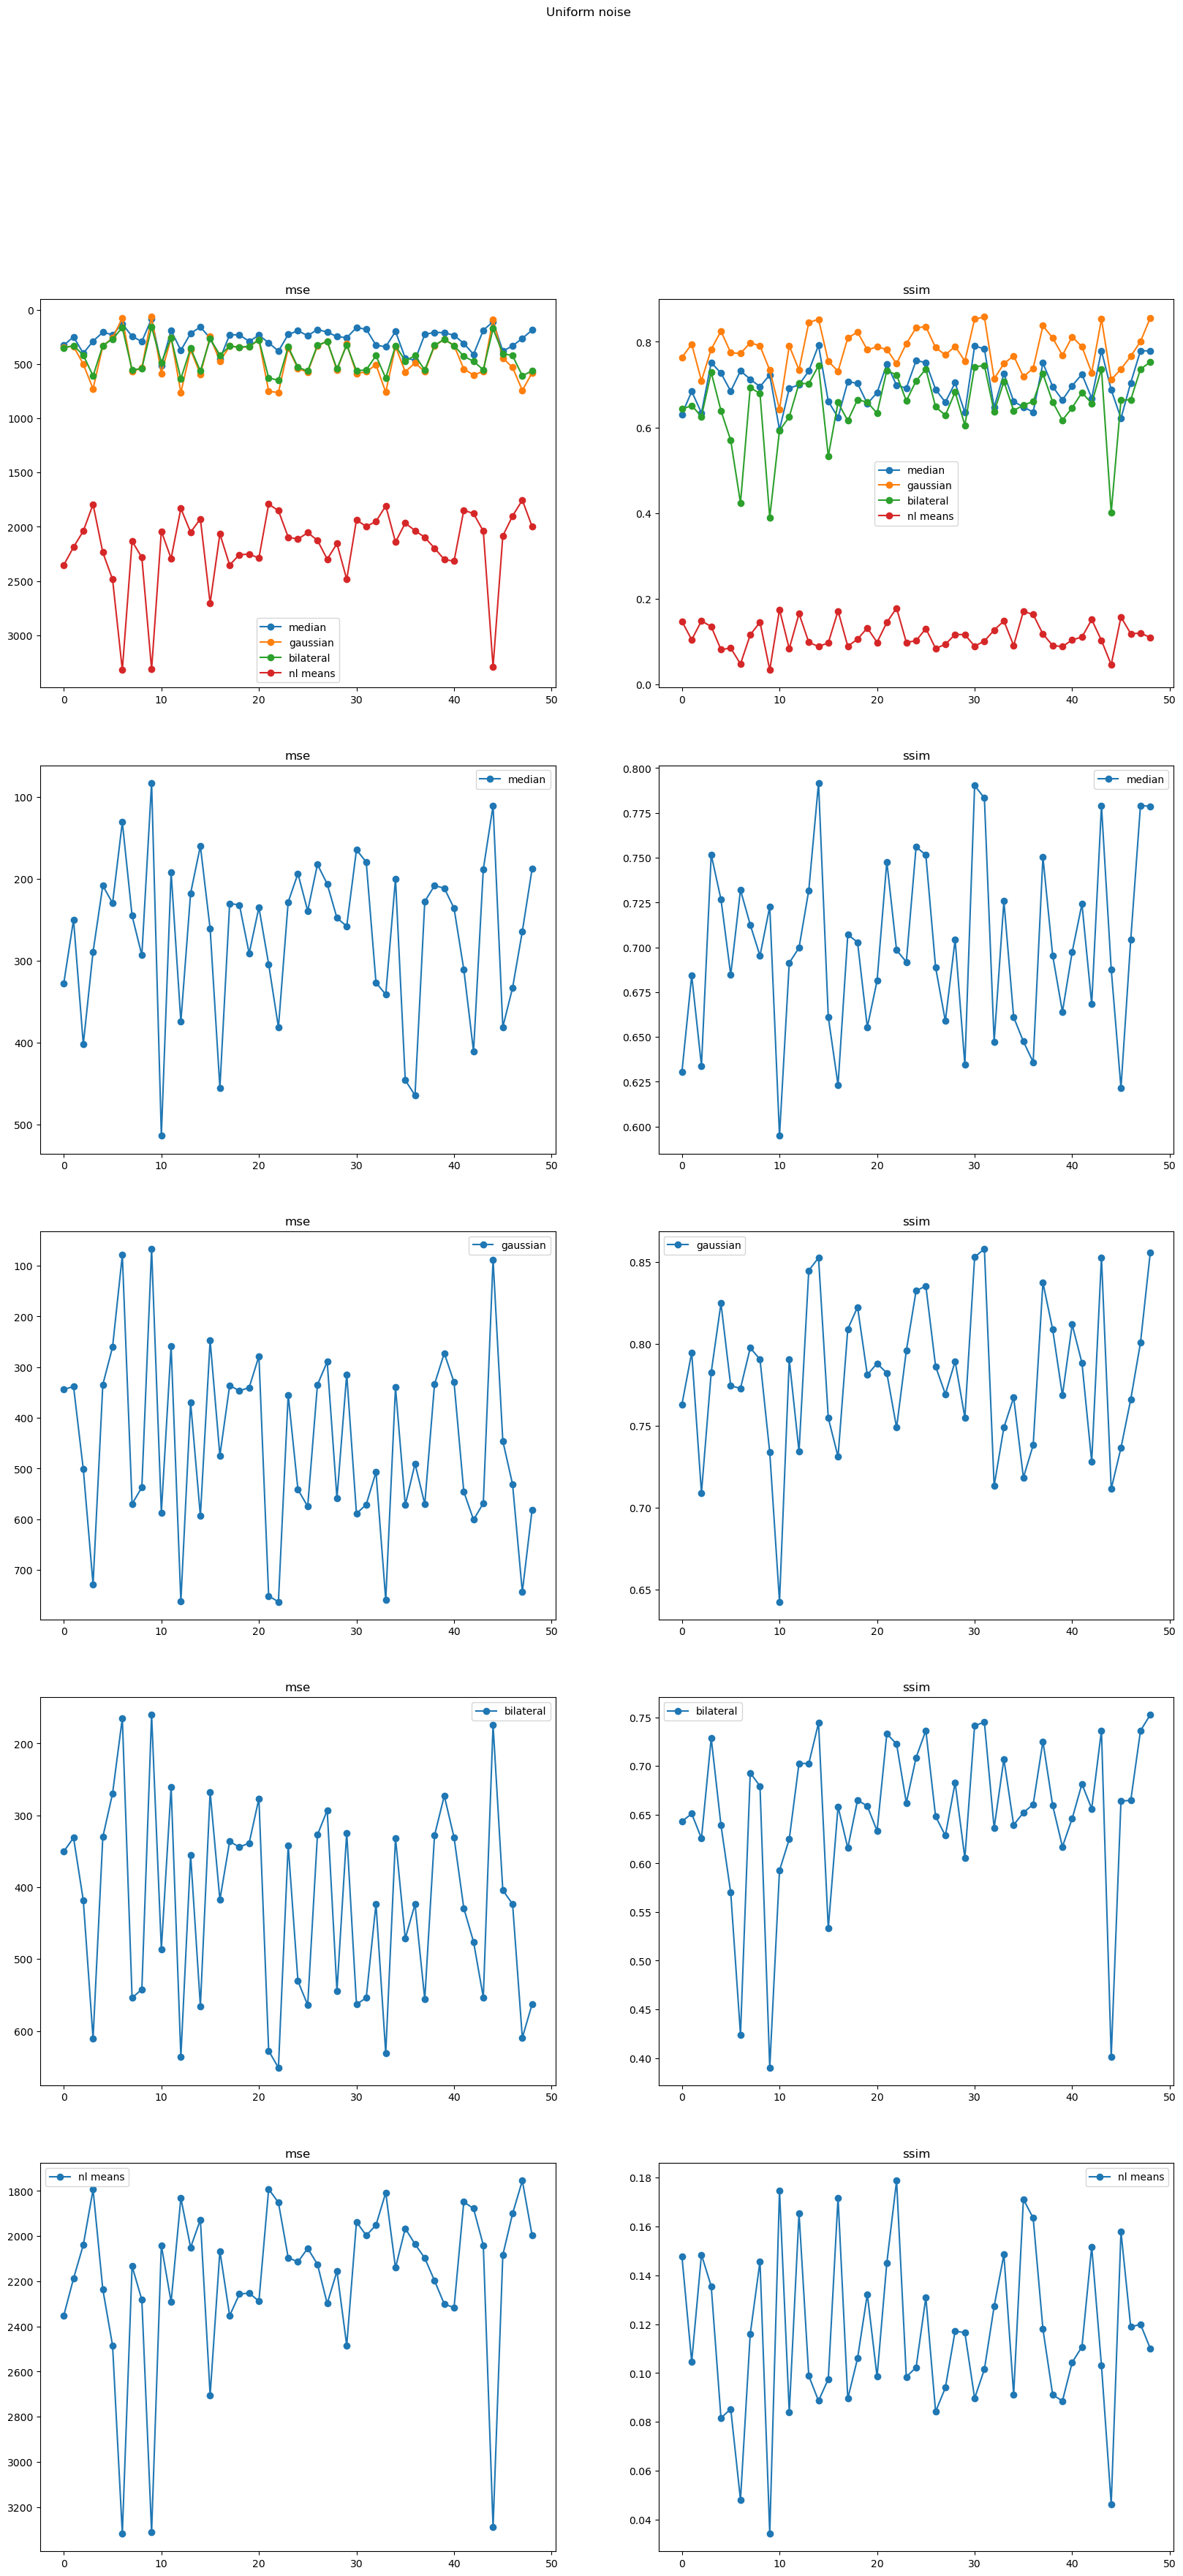

In [70]:
plot_denoising_result_specific_type(denoise_results, noise_types_int, 1, "Uniform noise")

In [80]:
def get_denoise_results_mean(denoise_results, mask):
    for key, item in denoise_results.items():
        print(
            f"{key} mean:"+ 
            f"mse={np.mean(item["best_mse"][mask])}, "+
            f"ssim={np.mean(item["best_ssim"][mask])}, "+
            f"best params mse: {np.mean(item["best_params_mse"][mask], axis=0)}, "+
            f"best params ssim: {np.mean(item["best_params_ssim"][mask], axis=0)}"
        )

In [81]:
print("OVERALL")
get_denoise_results_mean(denoise_results, noise_types_int >= 0)

OVERALL
median mean:mse=209.82877720833335, ssim=0.745993018842081, best params mse: [8.58], best params ssim: [14.74]
gaussian mean:mse=364.8741959791667, ssim=0.7948804738717032, best params mse: [8.52], best params ssim: [15.]
bilateral mean:mse=332.3294591250001, ssim=0.6834930236997251, best params mse: [124.], best params ssim: [150.]
nl means mean:mse=1936.3020074791666, ssim=0.12056582900400871, best params mse: [], best params ssim: []


In [82]:
print("Gauss noise")
get_denoise_results_mean(denoise_results, noise_types_int == 0)

Gauss noise
median mean:mse=155.33827871732026, ssim=0.7904043262306977, best params mse: [8.21568627], best params ssim: [14.52941176]
gaussian mean:mse=278.5690996732026, ssim=0.8085713767652516, best params mse: [8.60784314], best params ssim: [15.]
bilateral mean:mse=244.98104044117648, ssim=0.7122540742147123, best params mse: [119.01960784], best params ssim: [150.]
nl means mean:mse=1704.361937132353, ssim=0.12592262455901918, best params mse: [], best params ssim: []


In [83]:
print("Uniform noise")
get_denoise_results_mean(denoise_results, noise_types_int == 1)

Uniform noise
median mean:mse=266.54337767857146, ssim=0.699769005029439, best params mse: [8.95918367], best params ssim: [14.95918367]
gaussian mean:mse=454.7019492772109, ssim=0.7806307586151527, best params mse: [8.42857143], best params ssim: [15.]
bilateral mean:mse=423.2431193877551, ssim=0.6535580527555549, best params mse: [129.18367347], best params ssim: [150.]
nl means mean:mse=2177.709019472789, ssim=0.11499038873246716, best params mse: [], best params ssim: []
